In [1]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad

from tqdm import tqdm
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict

# 1. 加载 autoreload 扩展
%load_ext autoreload
# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2


sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

from data_preprocess import filter_jaspar_tf

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/original/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/benchmark/"

os.makedirs(output_path, exist_ok=True )

# Data read

In [6]:
adata_rna = ad.read_h5ad(data_path + "rna_processed.h5ad")

adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")

gene_info = pd.read_pickle(data_path + "gene_info_filtered.pkl")

# 读取整个文件
tf_chip_seq = pd.read_parquet(data_path + "combined_chip_seq.parquet")

tf_chip_df = tf_chip_seq[["chrom", "start", "end", "tf_name"]].copy()

tf_peak_network = ad.read_h5ad(data_path + "tf_peak_network.h5ad")

hic_data_df = pd.read_pickle(data_path + 'hic_data.pkl')

peak_gene_grn = ad.read_h5ad(data_path + "peak_gene_network.h5ad")

tf_peak_grn = ad.read_h5ad(data_path + "tf_peak_network.h5ad")

peak_gene_grn = ad.read_h5ad(data_path + "peak_gene_network.h5ad")

tf_gene_grn = ad.read_h5ad(data_path + "tf_gene_network.h5ad")

# Data preprocess

## TF recovery

In [2]:
from data_read import read_unibind_file

unibind_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/unibind/UniBind_search_qlr7ymfp.tar.gz"

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

print(unibind_df)
print(count_region_df)

unibind_df.to_pickle(output_path + "unibind_df.pkl")
count_region_df.to_pickle(output_path + "count_region_df.pkl")


********** 开始读取数据...
正在读取压缩包: /home/liyang/BioWuYan/dygmamba_project/data/Unibind/GM12878_UniBind_search_0_998agt.tar.gz ...
处理完成！
共提取了 78 个 TF 的数据。
总 Region 数量: 2149506
        chrom      start        end     TF CellLine     SourceID
0        chr1     869917     869936   CTCF  GM12878  ENCSR000AKB
1        chr1     904767     904786   CTCF  GM12878  ENCSR000AKB
2        chr1     938241     938260   CTCF  GM12878  ENCSR000AKB
3        chr1     976207     976226   CTCF  GM12878  ENCSR000AKB
4        chr1     984316     984335   CTCF  GM12878  ENCSR000AKB
...       ...        ...        ...    ...      ...          ...
2149501  chrX  155728737  155728750  NFKB2  GM12878    EXP054689
2149502  chrX  155881331  155881344  NFKB2  GM12878    EXP054689
2149503  chrY   11320906   11320919  NFKB2  GM12878    EXP054689
2149504  chrY   56842272   56842285  NFKB2  GM12878    EXP054689
2149505  chrY   56871003   56871016  NFKB2  GM12878    EXP054689

[2149506 rows x 6 columns]
   CellLine      TF  P

In [3]:
tf_peak_grn = ad.read_h5ad(data_path + "tf_peak_network.h5ad")
tf_peak_grn

AnnData object with n_obs × n_vars = 71541 × 112
    uns: 'description'

         peak_counts
TF_Name             
ELF1           55172
RUNX3          54484
ATF7           51456
TBX21          50821
CREB1          49441
...              ...
SP2             6433
E2F8            4868
NFYA            4116
RFX1            3750
NR3C1            757

[112 rows x 1 columns]


In [6]:
from data_preprocess import calculate_recovery_metrics

predicted_tfs = set(tf_peak_grn.var_names)
ground_truth_ranked = count_region_df.sort_values(by="PeakCount", ascending=False)["TF"].tolist()
# --- 运行计算 ---
x, y, raw_auc, norm_auc = calculate_recovery_metrics(ground_truth_ranked, predicted_tfs, top_n=40)

print(f"Top 40 AUC (Raw): {raw_auc:.2f}")
print(f"Top 40 AUC (Normalized): {norm_auc:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# 绘制我们的方法的曲线
plt.plot(x, y, label=f'Dygmamba (AUC={norm_auc:.2f})', color='dodgerblue', linewidth=2, marker='o', markersize=4)

# 绘制“随机猜测”基线 (Random Baseline)
# 假设总共有 N 个 TF，我们预测了 M 个。随机选一个选中的概率是 M/N。
total_tfs_pool = len(ground_truth_ranked) # 假设全集
n_predicted = len(predicted_tfs)
random_prob = n_predicted / total_tfs_pool
plt.plot([0, 40], [0, 40 * random_prob], 'k--', label='Random Chance', alpha=0.5)

# 绘制“完美预测”基线 (Perfect Recovery)
plt.plot([0, 40], [0, 40], 'g:', label='Perfect Recovery', alpha=0.5)

plt.xlabel('Rank in UniBind / logFC (Top 40)', fontsize=12)
plt.ylabel('Cumulative Number of Recovered TFs', fontsize=12)
plt.title('TF Recovery Curve', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 40)
plt.ylim(0, 40) # 或者是实际恢复的最大值
plt.show()

Top 40 AUC (Raw): 688.50
Top 40 AUC (Normalized): 0.8612


         peak_counts
TF_Name             
ELF1           55172
RUNX3          54484
ATF7           51456
TBX21          50821
CREB1          49441
...              ...
SP2             6433
E2F8            4868
NFYA            4116
RFX1            3750
NR3C1            757

[112 rows x 1 columns]


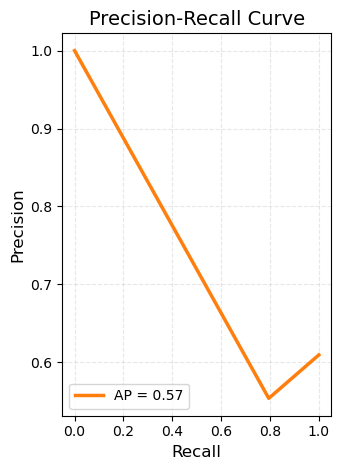

In [18]:
import scipy.sparse
import numpy as np
from sklearn.metrics import auc, precision_recall_curve, average_precision_score

col_sums = tf_peak_grn.X.sum(axis=0)
# 2. 处理稀疏矩阵格式 (如果是 np.matrix 需要展平)
if scipy.sparse.issparse(tf_peak_grn.X):
    col_sums = col_sums.A1  # 展平为一维数组
else:
    col_sums = np.asarray(col_sums).flatten()

# 3. 存入 var
tf_peak_grn.var['peak_counts'] = col_sums

dygmamba_df = tf_peak_grn.var[['peak_counts']].copy()
dygmamba_df = dygmamba_df.sort_values(by='peak_counts', ascending=False)
print(dygmamba_df)


all_tfs = list(predicted_tfs | set(ground_truth_ranked))
top_k_truth = 100 
y_true = np.array([1 if tf in ground_truth_ranked[:top_k_truth] else 0 for tf in all_tfs])
y_scores = np.array([1 if tf in predicted_tfs else 0 for tf in all_tfs])

# 计算 PR
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap_score = average_precision_score(y_true, y_scores)

# --- 子图 2: Precision-Recall Curve ---
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='#ff7f0e', linewidth=2.5, label=f'AP = {ap_score:.2f}')
plt.title('Precision-Recall Curve', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



## TF region

In [51]:
jaspar_tf_region_file = data_path + "jaspar_data.h5ad"
jaspar_data = ad.read_h5ad(jaspar_tf_region_file)
adata_region_tf = filter_jaspar_tf(jaspar_data)


coo_matrix = adata_region_tf.X.tocoo()
tf_peak_df = pd.DataFrame({
    'Peak': adata_region_tf.obs_names[coo_matrix.row],
    'TF': adata_region_tf.var_names[coo_matrix.col],
    'value': coo_matrix.data
})
tf_peak_df = tf_peak_df[tf_peak_df["Peak"].isin(set(adata_atac.var_names))]

print("*"*50)
print(adata_region_tf)
print(tf_peak_df.head())
print("*"*50)
print(f"TF-Peak: {tf_peak_df['TF'].nunique()}, {tf_peak_df['Peak'].nunique()}, edge: {len(tf_peak_df)}")
print("*"*50)

/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



步骤 1: 过滤 Peaks (行)
  > 找到 72563 / 72584 个 peaks 至少有 1 个 TF 结合。


/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



步骤 2: 过滤 TFs (列)
  > 找到 879 / 879 个 TFs 至少结合 1 个 peak。


/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  > 最终形状: (72563, 879)
**************************************************
AnnData object with n_obs × n_vars = 72563 × 879
    uns: 'description'
                   Peak         TF  value
501  chr1-629315-630015  FOSB::JUN      1
502  chr1-629315-630015      Hmga1      1
503  chr1-629315-630015    BHLHA15      1
504  chr1-629315-630015      BATF3      1
505  chr1-629315-630015      Foxj2      1
**************************************************
TF-Peak: 828, 71541, edge: 54310322
**************************************************


In [5]:
from network_construct import build_tf_peak_network

# 读取整个文件
adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")
tf_chip_seq = pd.read_parquet("/home/liyang/BioWuYan/dygmamba_project/data/code/combined_tf_peaks_new.parquet")
gm12878_chip_seq = tf_chip_seq[tf_chip_seq['cell_type']=='GM12878'].copy()

gm12878_chip_seq = gm12878_chip_seq[["chrom", "start", "end", "tf_name"]].copy()
# gm12878_chip_seq.rename(columns={'tf_name':'tf'},inplace = True)
# gm12878_chip_seq = gm12878_chip_seq[['tf','chrom','start','end']].copy()

# chip_seq_tf_peak_grn = build_tf_peak_network(gm12878_chip_seq, adata_atac)

# chip_seq_tf_peak_grn.to_pickle(output_path + 'chip_seq_tf_peak_data.pkl')


In [4]:
tf_chip_seq

,chrom,start,end,name,score,strand,signalValue,pValue,qValue,peak,tf_name,cell_type
0,chr8,47960406,47961010,.,1000,.,1418.58008,-1.0,2.89376,311,E2F8,MCF-7
1,chr6,52284601,52285124,.,1000,.,1182.47040,-1.0,2.89376,285,E2F8,MCF-7
2,chr17,58007385,58007815,.,1000,.,890.08641,-1.0,2.89376,243,E2F8,MCF-7
3,chr11,71928256,71928782,.,1000,.,879.71081,-1.0,2.89376,299,E2F8,MCF-7
4,chr1,212035510,212036039,.,1000,.,809.51726,-1.0,2.89376,237,E2F8,MCF-7
...,...,...,...,...,...,...,...,...,...,...,...,...
25090957,chr3,102612400,102612880,.,21,.,6.24183,-1.0,-0.00938,240,REST,Panc1
25090958,chr5,21093079,21093559,.,21,.,5.91522,-1.0,0.01098,240,REST,Panc1
25090959,chr6,151660647,151661127,.,21,.,5.61627,-1.0,0.01896,240,REST,Panc1
25090960,chr9,112791823,112792303,.,21,.,5.30545,-1.0,0.03569,240,REST,Panc1


In [48]:
unibind_chip_df = unibind_df[unibind_df['TF'].isin(set(gm12878_chip_seq["tf_name"]))].copy()
unibind_chip_df = unibind_chip_df[["chrom", "start", "end", "TF"]].copy()
unibind_chip_df.rename(columns={'TF':'tf'},inplace = True)
unibind_chip_df = unibind_chip_df[['tf','chrom','start','end']].copy()

unibind_tf_peak_grn = build_tf_peak_network(unibind_chip_df, adata_atac)

unibind_tf_peak_grn[['chrom', 'start', 'end']] = unibind_tf_peak_grn['peak_id'].str.split('-', expand=True)

# 2. (推荐) 将 start 和 end 列转换为整数类型，方便后续计算
unibind_tf_peak_grn['start'] = unibind_tf_peak_grn['start'].astype(int)
unibind_tf_peak_grn['end'] = unibind_tf_peak_grn['end'].astype(int)
unibind_tf_peak_grn.rename(columns={'tf':'TF'},inplace = True)
print(unibind_tf_peak_grn)

# unibind_tf_peak_grn.to_pickle(output_path + 'unibind_tf_peak_data.pkl')

--- 1. 构建 TF-Peak 网络 ---


In [57]:
unibind_tf_peak_grn.rename(columns={'tf':'TF'},inplace = True)

from analysis.assess import calculate_tf_metrics
results = calculate_tf_metrics(tf_peak_df, unibind_tf_peak_grn)
print(results)


正在解析 Consensus Peaks 坐标...
共发现 43 个共有 TF，开始评估...
         TF  Precision    Recall        F1     TP     FP     FN  \
0     NR2C1   0.031003  1.000000  0.060142   2210  69073      0   
1      USF1   0.064891  0.999783  0.121872   4609  66418      1   
2       SRF   0.182493  0.400699  0.250775   2752  12328   4116   
3     MEF2A   0.212230  0.999329  0.350106  14900  55307     10   
4      IRF4   0.452281  0.295363  0.357355   6682   8092  15941   
5     GABPA   0.344045  1.000000  0.511955  24613  46927      0   
6      EGR1   0.169997  1.000000  0.290594  11971  58448      0   
7      EBF1   0.383182  0.999853  0.554036  27163  43725      4   
8      ETV6   0.269487  1.000000  0.424561  19160  51938      0   
9      PBX3   0.199172  1.000000  0.332183  14246  57280      0   
10     CREM   0.260699  0.999300  0.413519  18561  52636     13   
11    MEF2C   0.084576  1.000000  0.155961   5769  62442      0   
12    RUNX3   0.461833  1.000000  0.631855  33040  38501      0   
13     E2F4  

In [ ]:
from src.network_construct import build_peak_gene_network_mem_efficient

peak_gene_grn = build_peak_gene_network_mem_efficient(hic_data_df, adata_atac, gene_info) 

peak_gene_grn.to_pickle(output_path + 'new_peak_gene_data.pkl')

In [ ]:
from src.network_construct import new_build_tf_gene_network_mem_efficient

tf_gene_grn = new_build_tf_gene_network_mem_efficient(tf_peak_grn, peak_gene_grn)

tf_gene_grn.to_pickle(output_path + 'tf_gene_data.pkl')

tf_gene_grn

# Other

In [2]:
data_path = "/home/liyang/BioWuYan/dygmamba_project/data/original/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/benchmark/"

unibind_df_file = "/home/liyang/BioWuYan/dygmamba_project/data/benchmark/unibind_df.pkl"

model_result_path = "/home/liyang/BioWuYan/dygmamba_project/data/dygmamba/res/result2/"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(model_result_path + "atac.h5ad")
adata_rna = ad.read_h5ad(model_result_path + "rna.h5ad")
total_peak = set(adata_atac.var_names)

avg_active_tf_gene_grn = pd.read_pickle(model_result_path + "average_active_tf_gene_grn.pkl")
avg_global_tf_gene_grn = pd.read_pickle(model_result_path + "average_global_tf_gene_grn.pkl")



In [6]:
active_grn = avg_active_tf_gene_grn[["TF","Gene"]].copy()

active_grn.rename(columns={'Gene':'Target'},inplace = True)
matrix_df = pd.DataFrame(adata_rna.X.toarray(), index=adata_rna.obs_names, columns=adata_rna.var_names)

In [7]:
matrix_df

Geneid,HNRNPA0,ANK1,ZNF263,NAPG,CACNA2D1,NDUFS5,VPS35L,DPP9,CYLD,IQGAP1,...,ELF2,SPI1,MCUR1,IVD,CHTOP,APOOL,RFC1,KIF3A,TXNDC9,METTL14
cell_247,3,0,1,1,0,0,0,2,2,3,...,2,0,0,1,2,0,1,0,0,0
cell_164,2,0,0,0,0,1,0,2,3,3,...,1,0,0,1,0,0,2,2,0,0
cell_44,2,0,1,2,1,2,2,0,1,5,...,0,0,1,0,3,0,1,0,0,0
cell_263,1,0,0,1,0,1,0,1,6,3,...,2,0,1,1,0,0,0,1,1,1
cell_192,2,0,0,2,0,0,0,4,3,5,...,1,2,0,0,0,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_210,1,1,2,0,1,1,0,2,1,4,...,2,0,1,1,1,0,0,1,0,1
cell_239,0,0,1,3,0,0,0,7,1,5,...,0,0,0,0,1,0,0,0,0,0
cell_257,1,1,0,0,0,0,1,3,3,3,...,0,0,0,1,0,0,1,0,0,0
cell_97,2,0,0,0,0,0,1,1,5,6,...,0,3,0,0,1,0,1,0,0,1
